# PTM for OpenMMDL

Version 1:
Hier werden LIG.sdf und PROTLIG.pdb eingelesen. Mit Ketcher wird die Reaktion gezeichnet.
Die Idee ist, dass direkt gemapte SMARTS von Reaktanden und Produkten ausgegeben werden.


Erstmal benutze ich Ketcher als Webtool mit streamlit - ketcher.
ipyketcher hat in der VSC - Notebook enviroment nicht funktioniert.

In Ketcher nach malen der Strukturen muss man reaction auto mapping anstellen.


## Fragen
- Wie muss ich die Residue zeichnen?




In [4]:
# Load files
LIGsdf = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/maleimide.sdf"
PROTLIGpdb = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/ip9_dye.pdb"

In [3]:
# Function that splits a SMARTS string into its components based on the '.' and the '>>' delimiter

def split_smarts(smarts: str):
    reactants, products = smarts.split('>>')
    reactant_smarts = reactants.split('.')
    product_smarts = products.split('.')
    return reactant_smarts, product_smarts

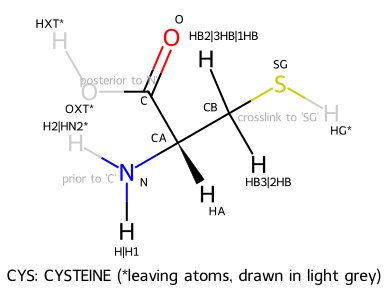

In [8]:
# Test if the smarts can be used in OpenMM

from openff.pablo import STD_CCD_CACHE

cysteine_resdef = STD_CCD_CACHE["CYS"][0]
cysteine_resdef.visualize()

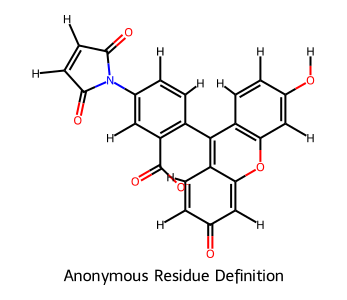

In [9]:
from openff.pablo import ResidueDefinition

maleimide_resdef = ResidueDefinition.anon_from_sdf(LIGsdf)
maleimide_resdef.visualize()

In [5]:
reaction_smiles = '[CH2:1]([NH:7][CH3:9])[C@@H:2]([CH2:5][SH:6])[C:3]([CH3:8])=[O:4].[C:10]1([C:52](=[O:53])[N:16]([C:17]2[C:50]([H])=[C:46]([C:47]([O-:49])=[O:48])[C:22]([C:23]3[C:45]4[C:35](=[C:36]([C:38](=[C:41]([C:43]=4[H])[H])[O:39][H])[H])[O:34][C:33]4[C:24]=3[C:25](=[C:27]([C:29]([C:31]=4[H])=[O:30])[H])[H])=[C:20]([H])[C:18]=2[H])[C:14](=[O:15])[C:12]=1[H])[H]>>[C@@H:10]1([S:6][CH2:5][C@@H:2]([C:3]([CH3:8])=[O:4])[CH2:1][NH:7][CH3:9])[C:52](=[O:53])[N:16]([C:17]2[C:50]([H])=[C:46]([C:47]([O-:49])=[O:48])[C:22]([C:23]3[C:45]4[C:35](=[C:36]([C:38](=[C:41]([C:43]=4[H])[H])[O:39][H])[H])[O:34][C:33]4[C:24]=3[C:25](=[C:27]([C:29]([C:31]=4[H])=[O:30])[H])[H])=[C:20]([H])[C:18]=2[H])[C:14](=[O:15])[CH:12]1[H]'
reactant_smarts, product_smarts = split_smarts(reaction_smiles)

print("Reactant SMARTS:", reactant_smarts)
print("Product SMARTS:", product_smarts)

dye_resdef = ResidueDefinition.react(
    reactants=[cysteine_resdef, maleimide_resdef],
    reactant_smarts = [
        reactant_smarts[0], 
        reactant_smarts[1],
    ],
    product_smarts = [
        product_smarts[0],
    ],
)[0][0] # Returns a list of tuples, we want the first (and only) element of any (identical) tuple
dye_resdef.visualize()

Reactant SMARTS: ['[CH2:1]([NH:7][CH3:9])[C@@H:2]([CH2:5][SH:6])[C:3]([CH3:8])=[O:4]', '[C:10]1([C:52](=[O:53])[N:16]([C:17]2[C:50]([H])=[C:46]([C:47]([O-:49])=[O:48])[C:22]([C:23]3[C:45]4[C:35](=[C:36]([C:38](=[C:41]([C:43]=4[H])[H])[O:39][H])[H])[O:34][C:33]4[C:24]=3[C:25](=[C:27]([C:29]([C:31]=4[H])=[O:30])[H])[H])=[C:20]([H])[C:18]=2[H])[C:14](=[O:15])[C:12]=1[H])[H]']
Product SMARTS: ['[C@@H:10]1([S:6][CH2:5][C@@H:2]([C:3]([CH3:8])=[O:4])[CH2:1][NH:7][CH3:9])[C:52](=[O:53])[N:16]([C:17]2[C:50]([H])=[C:46]([C:47]([O-:49])=[O:48])[C:22]([C:23]3[C:45]4[C:35](=[C:36]([C:38](=[C:41]([C:43]=4[H])[H])[O:39][H])[H])[O:34][C:33]4[C:24]=3[C:25](=[C:27]([C:29]([C:31]=4[H])=[O:30])[H])[H])=[C:20]([H])[C:18]=2[H])[C:14](=[O:15])[CH:12]1[H]']


NameError: name 'cysteine_resdef' is not defined

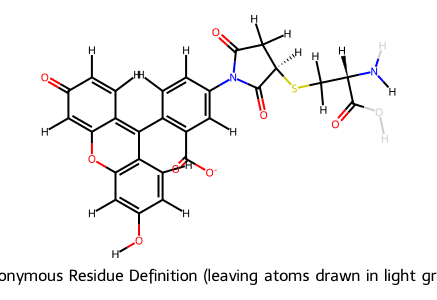

In [13]:
dye_resdef = ResidueDefinition.react(
    reactants=[cysteine_resdef, maleimide_resdef],
    reactant_smarts = [
        "[C:10]-[S:1]-[H:2]",
        "[N:3]1-[C:4](=[O:5])-[C:6](-[H:11])=[C:7](-[H:12])-[C:8](=[O:9])-1",
    ],
    product_smarts = [
        "[N:3]1-[C:4](=[O:5])-[C:6](-[H:2])(-[H:11])-[C@:7](-[S:1]-[C:10])(-[H:12])-[C:8](=[O:9])-1",
    ],
)[0][0] # Returns a list of tuples, we want the first (and only) element of any (identical) tuple
dye_resdef.visualize()

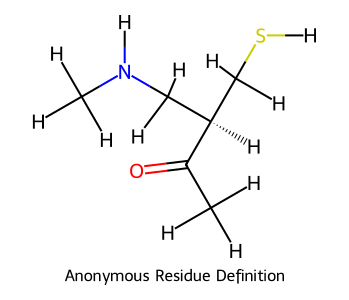

In [6]:
from openff.pablo import ResidueDefinition

reaction_smiles = '[CH2:1]([NH:7][CH3:9])[C@@H:2]([CH2:5][SH:6])[C:3]([CH3:8])=[O:4].[C:10]1([C:52](=[O:53])[N:16]([C:17]2[C:50]([H])=[C:46]([C:47]([O-:49])=[O:48])[C:22]([C:23]3[C:45]4[C:35](=[C:36]([C:38](=[C:41]([C:43]=4[H])[H])[O:39][H])[H])[O:34][C:33]4[C:24]=3[C:25](=[C:27]([C:29]([C:31]=4[H])=[O:30])[H])[H])=[C:20]([H])[C:18]=2[H])[C:14](=[O:15])[C:12]=1[H])[H]>>[C@@H:10]1([S:6][CH2:5][C@@H:2]([C:3]([CH3:8])=[O:4])[CH2:1][NH:7][CH3:9])[C:52](=[O:53])[N:16]([C:17]2[C:50]([H])=[C:46]([C:47]([O-:49])=[O:48])[C:22]([C:23]3[C:45]4[C:35](=[C:36]([C:38](=[C:41]([C:43]=4[H])[H])[O:39][H])[H])[O:34][C:33]4[C:24]=3[C:25](=[C:27]([C:29]([C:31]=4[H])=[O:30])[H])[H])=[C:20]([H])[C:18]=2[H])[C:14](=[O:15])[CH:12]1[H]'
reactant_smarts, product_smarts = split_smarts(reaction_smiles)
maleimide_resdef = ResidueDefinition.anon_from_smiles(reactant_smarts[0])
maleimide_resdef.visualize()
